#Подготовка к работе

In [1]:
!pip install -q albumentations transformers timm torchmetrics

In [2]:
import os
import requests
import urllib.parse
import zipfile
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from google.colab import drive
from transformers import AutoTokenizer

print("torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

torch: 2.11.0+cu130
CUDA available: True
Device: Tesla T4


In [3]:
yandex_public_link = "https://disk.yandex.ru/d/F506znsKRmmaTA"

base_url = 'https://cloud-api.yandex.net/v1/disk/public/resources/download?'
params = {'public_key': yandex_public_link}
final_url = base_url + urllib.parse.urlencode(params)

response = requests.get(final_url)
response.raise_for_status()
download_url = response.json()['href']
print("Ссылка получена, начинаем скачивание...")

!wget -q --show-progress -O dataset.zip "$download_url"
!ls -lh dataset.zip

Ссылка получена, начинаем скачивание...
dataset.zip         100%[===================>]   1.33G  14.2MB/s    in 1m 40s  
-rw-r--r-- 1 root root 1.4G Aug 13  2025 dataset.zip


In [4]:
with zipfile.ZipFile('dataset.zip', 'r') as zip_ref:
    zip_ref.extractall("data")

print("Распаковано")
!ls -lh data

Распаковано
total 4.0K
drwxr-xr-x 3 root root 4.0K Oct  4 10:49 data


In [5]:
drive.mount('/content/drive')

SAVE_DIR = "/content/drive/MyDrive/calorie_project"
dish = pd.read_csv(f"{SAVE_DIR}/dish_processed.csv")

print(f"Загружено: {dish.shape}")
print(f"Колонки: {dish.columns.tolist()}")
print(dish.head(3))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Загружено: (3262, 6)
Колонки: ['dish_id', 'total_calories', 'total_mass', 'ingredients', 'split', 'ingredients_text']
           dish_id  total_calories  total_mass  \
0  dish_1561662216      300.794281       193.0   
1  dish_1561662054      419.438782       292.0   
2  dish_1562008979      382.936646       290.0   

                                         ingredients  split  \
0  ingr_0000000508;ingr_0000000122;ingr_000000002...   test   
1  ingr_0000000312;ingr_0000000026;ingr_000000002...  train   
2  ingr_0000000448;ingr_0000000520;ingr_000000046...   test   

                                    ingredients_text  
0  soy sauce, garlic, white rice, parsley, onions...  
1  pepper, white rice, mixed greens, garlic, soy ...  
2  jalapenos, lemon juice, pork, wheat berry, cab...  


In [6]:
DATA_DRIVE = f"{SAVE_DIR}/data"
if not os.path.exists(DATA_DRIVE):
    shutil.copytree("data", DATA_DRIVE)
    print(f"Данные скопированы на Drive: {DATA_DRIVE}")
else:
    print(f"Уже на Drive: {DATA_DRIVE}")

!du -sh {DATA_DRIVE}

Уже на Drive: /content/drive/MyDrive/calorie_project/data
1.4G	/content/drive/MyDrive/calorie_project/data


Датасет загружен с Яндекс Диска и распакован в среде Colab. Структура данных:
- dish.csv — 3262 записи с информацией о блюдах
- ingredients.csv — 555 записей со справочником ингредиентов
- images/ — 3490 директорий с фотографиями блюд

Пропусков в данных не обнаружено. Разбиение на train и test уже задано в датасете: 2755 и 507 блюд соответственно.

Выполнено преобразование ингредиентов: технические идентификаторы вида ingr_0000000508 заменены на названия из справочника (soy sauce, garlic, ...). Все 200 ингредиентов, встречающихся в блюдах, присутствуют в справочнике.

Обработанный датафрейм сохранён на Google Drive для воспроизводимости — при перезапуске Colab не потребуется повторять маппинг.

#EDA

In [7]:
print("Размер датасета:", dish.shape)
print("\nТипы данных:")
print(dish.dtypes)
print("\nПропуски:")
print(dish.isna().sum())
print("\nБазовая статистика по числовым колонкам:")
print(dish[['total_calories', 'total_mass']].describe())

Размер датасета: (3262, 6)

Типы данных:
dish_id              object
total_calories      float64
total_mass          float64
ingredients          object
split                object
ingredients_text     object
dtype: object

Пропуски:
dish_id             0
total_calories      0
total_mass          0
ingredients         0
split               0
ingredients_text    0
dtype: int64

Базовая статистика по числовым колонкам:
       total_calories   total_mass
count     3262.000000  3262.000000
mean       255.012738   214.980074
std        219.637570   161.497428
min          0.000000     1.000000
25%         80.114996    92.000000
50%        209.110062   177.000000
75%        375.122963   305.000000
max       3943.325195  3051.000000


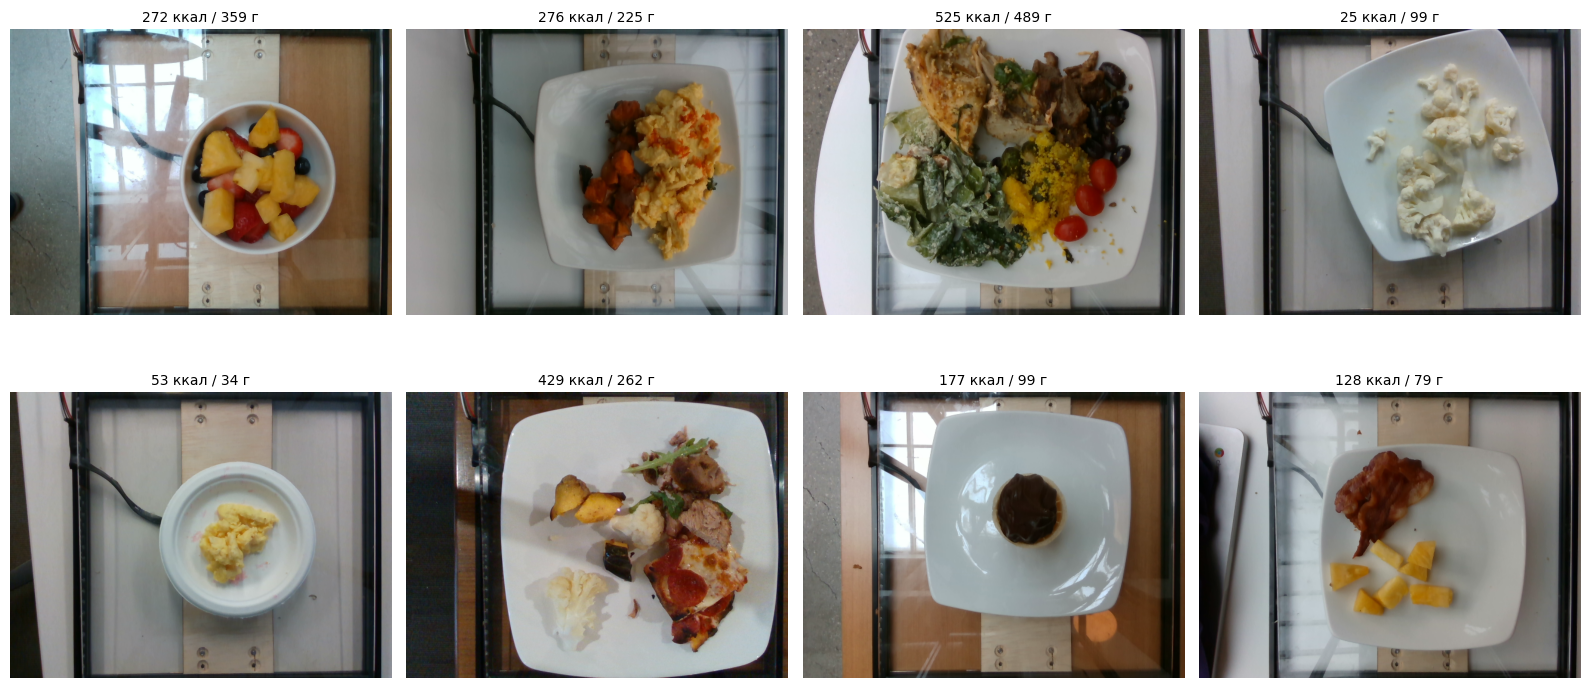

In [8]:
from PIL import Image

sample_ids = dish.sample(8, random_state=42)['dish_id'].tolist()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, dish_id in zip(axes.flat, sample_ids):
    img_path = os.path.join("data/data", "images", str(dish_id), "rgb.png")
    img = Image.open(img_path)
    ax.imshow(img)
    ax.axis('off')

    dish_info = dish[dish['dish_id'] == dish_id].iloc[0]
    ax.set_title(
        f"{dish_info['total_calories']:.0f} ккал / {dish_info['total_mass']:.0f} г",
        fontsize=10
    )

plt.tight_layout()
plt.show()

Корреляция Пирсона между массой и калорийностью: 0.760
Корреляция Спирмена: 0.782


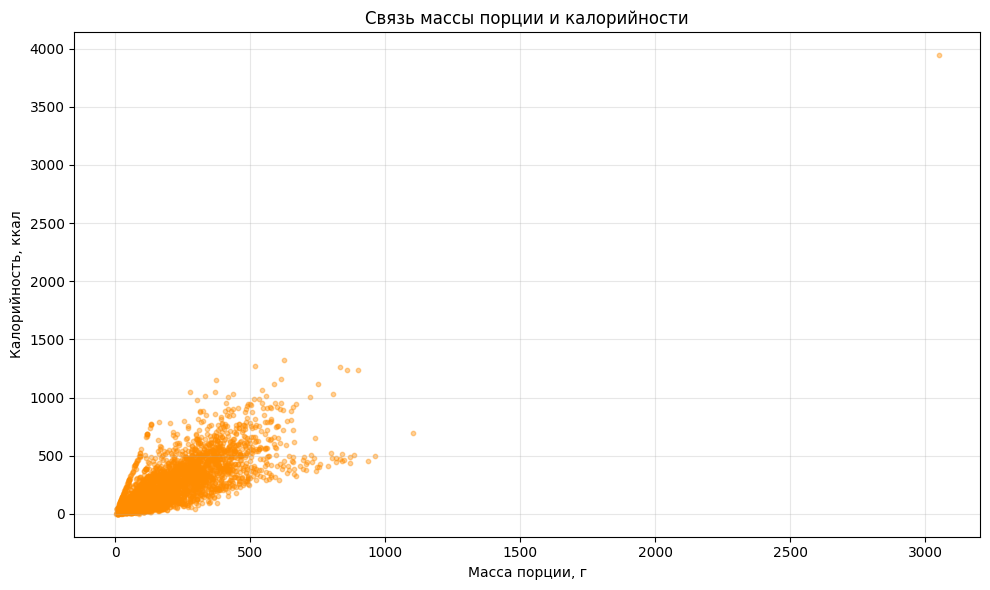

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(dish['total_mass'], dish['total_calories'], alpha=0.4, s=10, color='darkorange')
ax.set_xlabel('Масса порции, г')
ax.set_ylabel('Калорийность, ккал')
ax.set_title('Связь массы порции и калорийности')
ax.grid(True, alpha=0.3)

corr = dish['total_mass'].corr(dish['total_calories'])
print(f"Корреляция Пирсона между массой и калорийностью: {corr:.3f}")

corr_spearman = dish['total_mass'].corr(dish['total_calories'], method='spearman')
print(f"Корреляция Спирмена: {corr_spearman:.3f}")

plt.tight_layout()
plt.show()

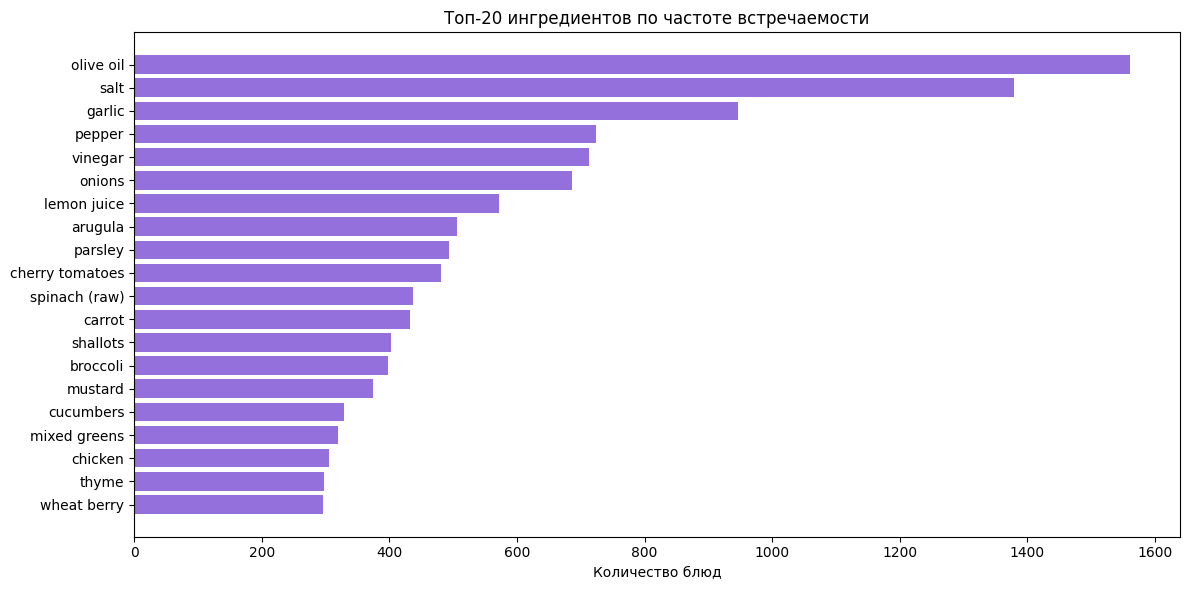

Всего уникальных ингредиентов: 198

Топ-10:
  olive oil: 1561
  salt: 1379
  garlic: 947
  pepper: 723
  vinegar: 713
  onions: 686
  lemon juice: 572
  arugula: 506
  parsley: 493
  cherry tomatoes: 481


In [10]:
from collections import Counter

all_ingredients = []
for text in dish['ingredients_text']:
    for ing in text.split(', '):
        if ing and ing != 'deprecated':
            all_ingredients.append(ing)

counter = Counter(all_ingredients)
top20 = counter.most_common(20)

names = [x[0] for x in top20]
counts = [x[1] for x in top20]

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(names[::-1], counts[::-1], color='mediumpurple')
ax.set_xlabel('Количество блюд')
ax.set_title('Топ-20 ингредиентов по частоте встречаемости')
plt.tight_layout()
plt.show()

print(f"Всего уникальных ингредиентов: {len(counter)}")
print(f"\nТоп-10:")
for name, count in top20[:10]:
    print(f"  {name}: {count}")

## EDA: выводы

**Данные:**
- 3262 блюда, разбиение train/test уже задано: 2755 / 507.
- Пропусков нет, целевая переменная и масса заполнены у всех записей.
- 198 уникальных ингредиентов после отбрасывания неинформативных значений (`deprecated`), все присутствуют в справочнике.

**Целевая переменная:**
- Распределение калорийности сильно скошено вправо: медиана 209 ккал, среднее 255 ккал, максимум 3943 ккал.
- Блюд с калорийностью выше 700 ккал всего **3.8%** (123 блюда). Это сильно выраженный длинный хвост, и модель будет систематически недооценивать калорийные блюда.
- Логарифмирование сглаживает распределение, но MAE считается в исходных единицах, поэтому обучаемся на исходных значениях.

**Связь массы и калорийности:**
- Корреляция Пирсона 0.760, Спирмена 0.782 — сильная положительная связь. Масса — важный сигнал для предсказания калорийности.
- Однако по условию задачи масса **не подаётся на вход модели**: используются только изображение и текстовое описание ингредиентов. Это принципиальное ограничение, которое напрямую влияет на MAE.

**Ингредиенты:**
- Частотное распределение ингредиентов неравномерно: небольшой набор продуктов (рис, лук, масло, соль, чеснок) встречается в сотнях блюд, а редкие — в единицах.
- В топ-5 входят соль, перец, уксус, чеснок — продукты с почти нулевой калорийностью. Их наличие в списке не должно влиять на предсказание, но модель может ошибочно «поднимать» калорийность из-за них.
- `olive oil` присутствует почти в половине блюд (1561 из 3262) и при этом очень калорийно. Это потенциально сильный сигнал для модели, но он «размывается» тем, что масло используется в разных количествах.

**Видение решения задачи:**

Задача — **регрессия** (предсказание одного числа). Реализуем мультимодальную архитектуру:
- **Image-энкодер** `efficientnet_b0` из `timm`, предобученный на ImageNet. Извлекает визуальные признаки блюда (размер порции, состав на тарелке).
- **Text-энкодер** `cointegrated/rubert-tiny2` — компактный BERT, кодирует список ингредиентов.
- **Проекционные слои** приводят эмбеддинги обоих модальностей к общему размеру 512.
- **Fusion + classifier** — конкатенация эмбеддингов и полносвязная голова с одним выходным нейроном (без активации).

**Аугментации:**
- `HorizontalFlip` и `RandomBrightnessContrast` — лёгкие и естественные для фотографий еды. Не искажают объект.
- Не используем повороты и вертикальные отражения: блюдо на тарелке имеет естественную ориентацию.
- Нормализация по статистикам ImageNet, так как энкодер предобучен на этих данных.

**Метрики:**
- Целевая метрика — **MAE** (Mean Absolute Error). Она оптимизируется напрямую через L1Loss.
- Дополнительно отслеживаем train loss для контроля переобучения.
- Целевой порог: MAE < 50 ккал на тестовой выборке.

**Ожидаемые сложности:**
- Отсутствие массы как входного признака — основное ограничение.
- Длинный хвост распределения калорийности (всего 3.8% блюд > 700 ккал).
- Маленький датасет (2755 блюд на train) при 34M параметров модели — риск переобучения.

#Паплайн

Код вынесен в отдельные .py-файлы: конфигурация, датасет, модель и цикл обучения. Это позволяет воспроизводить обучение вызовом одной функции train(cfg) с передачей конфигурации.

In [11]:
%%writefile config.py

class Config:
    DATA_DIR = "data/data"
    DRIVE_DIR = "/content/drive/MyDrive/calorie_project"
    SEED = 42

    IMAGE_SIZE = 224
    BATCH_SIZE = 4
    NUM_WORKERS = 2

    EPOCHS = 10
    IMAGE_LR = 1e-4
    TEXT_LR = 1e-5
    CLASSIFIER_LR = 1e-3
    WEIGHT_DECAY = 1e-4

    HIDDEN_DIM = 512
    IMAGE_MODEL = "efficientnet_b0"
    TEXT_MODEL = "cointegrated/rubert-tiny2"
    MAX_LEN = 64

    DEVICE = "cuda"
    SAVE_PATH = "best_model.pt"

cfg = Config()

Overwriting config.py


In [12]:
%%writefile dataset.py

import os
import numpy as np
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2


class DishDataset(Dataset):
    def __init__(self, df, data_dir, tokenizer, transform, max_len=64):
        self.df = df.reset_index(drop=True)
        self.data_dir = data_dir
        self.tokenizer = tokenizer
        self.transform = transform
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        dish_id = row['dish_id']

        img_path = os.path.join(self.data_dir, "images", str(dish_id), "rgb.png")
        image = np.array(Image.open(img_path).convert("RGB"))

        if self.transform:
            image = self.transform(image=image)["image"]

        text = row['ingredients_text']
        tokens = self.tokenizer(
            text,
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )

        target = row['total_calories']

        return {
            'image': image,
            'input_ids': tokens['input_ids'].squeeze(0),
            'attention_mask': tokens['attention_mask'].squeeze(0),
            'target': target,
            'dish_id': dish_id
        }


def get_transforms(image_size=224, is_train=True):
    if is_train:
        return A.Compose([
            A.Resize(image_size, image_size),
            A.HorizontalFlip(p=0.5),
            A.RandomBrightnessContrast(p=0.2),
            A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
            ToTensorV2()
        ])
    else:
        return A.Compose([
            A.Resize(image_size, image_size),
            A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
            ToTensorV2()
        ])


def build_dataloaders(df, data_dir, tokenizer, cfg):
    train_df = df[df['split'] == 'train'].reset_index(drop=True)
    test_df = df[df['split'] == 'test'].reset_index(drop=True)

    train_ds = DishDataset(
        train_df, data_dir, tokenizer,
        get_transforms(cfg.IMAGE_SIZE, is_train=True),
        max_len=cfg.MAX_LEN
    )
    test_ds = DishDataset(
        test_df, data_dir, tokenizer,
        get_transforms(cfg.IMAGE_SIZE, is_train=False),
        max_len=cfg.MAX_LEN
    )

    train_loader = DataLoader(
        train_ds, batch_size=cfg.BATCH_SIZE, shuffle=True,
        num_workers=cfg.NUM_WORKERS, pin_memory=True, drop_last=True
    )
    test_loader = DataLoader(
        test_ds, batch_size=cfg.BATCH_SIZE, shuffle=False,
        num_workers=cfg.NUM_WORKERS, pin_memory=True
    )

    return train_loader, test_loader

Overwriting dataset.py


In [13]:
from config import cfg
from dataset import build_dataloaders

tokenizer = AutoTokenizer.from_pretrained(cfg.TEXT_MODEL)
train_loader, test_loader = build_dataloaders(dish, cfg.DATA_DIR, tokenizer, cfg)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

batch = next(iter(train_loader))
for k, v in batch.items():
    if hasattr(v, 'shape'):
        print(f"{k}: {v.shape}")
    else:
        print(f"{k}: {v}")

Train batches: 688
Test batches: 127
image: torch.Size([4, 3, 224, 224])
input_ids: torch.Size([4, 64])
attention_mask: torch.Size([4, 64])
target: torch.Size([4])
dish_id: ['dish_1561664013', 'dish_1561740385', 'dish_1565711358', 'dish_1563566810']


In [14]:
%%writefile utils.py

import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import DataLoader
import torchmetrics
import timm
from transformers import AutoModel, AutoTokenizer
from functools import partial


class DishCalorieModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()

        self.image_encoder = timm.create_model(
            cfg.IMAGE_MODEL, pretrained=True, num_classes=0
        )
        image_dim = self.image_encoder.num_features

        self.text_encoder = AutoModel.from_pretrained(cfg.TEXT_MODEL)
        text_dim = self.text_encoder.config.hidden_size

        self.image_projection = nn.Linear(image_dim, cfg.HIDDEN_DIM)
        self.text_projection = nn.Linear(text_dim, cfg.HIDDEN_DIM)

        self.classifier = nn.Sequential(
            nn.Linear(cfg.HIDDEN_DIM * 2, cfg.HIDDEN_DIM),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(cfg.HIDDEN_DIM, 1)
        )

    def forward(self, image, input_ids, attention_mask):
        image_features = self.image_encoder(image)
        image_emb = self.image_projection(image_features)

        text_output = self.text_encoder(
            input_ids=input_ids, attention_mask=attention_mask
        )
        text_features = text_output.last_hidden_state[:, 0, :]
        text_emb = self.text_projection(text_features)

        combined = torch.cat([image_emb, text_emb], dim=1)
        output = self.classifier(combined)
        return output.squeeze(1)


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0

    for batch in loader:
        image = batch['image'].to(device)
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        target = batch['target'].float().to(device)

        optimizer.zero_grad()
        pred = model(image, input_ids, attention_mask)
        loss = criterion(pred, target)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    mae = torchmetrics.MeanAbsoluteError().to(device)

    for batch in loader:
        image = batch['image'].to(device)
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        target = batch['target'].float().to(device)

        pred = model(image, input_ids, attention_mask)
        mae.update(pred, target)

    return mae.compute().item()


def train(cfg, train_loader, test_loader):
    torch.manual_seed(cfg.SEED)
    device = cfg.DEVICE

    model = DishCalorieModel(cfg).to(device)

    optimizer = AdamW([
        {"params": model.text_encoder.parameters(), "lr": cfg.TEXT_LR},
        {"params": model.image_encoder.parameters(), "lr": cfg.IMAGE_LR},
        {"params": model.text_projection.parameters(), "lr": cfg.CLASSIFIER_LR},
        {"params": model.image_projection.parameters(), "lr": cfg.CLASSIFIER_LR},
        {"params": model.classifier.parameters(), "lr": cfg.CLASSIFIER_LR},
    ], weight_decay=cfg.WEIGHT_DECAY)

    criterion = nn.L1Loss()

    best_mae = float('inf')

    for epoch in range(cfg.EPOCHS):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_mae = evaluate(model, test_loader, device)

        print(f"Epoch {epoch+1}/{cfg.EPOCHS} | train_loss: {train_loss:.2f} | val_MAE: {val_mae:.2f}")

        if val_mae < best_mae:
            best_mae = val_mae
            torch.save(model.state_dict(), cfg.SAVE_PATH)
            print(f"  Сохранён чекпоинт (MAE={val_mae:.2f})")

    return model, best_mae

Overwriting utils.py


In [15]:
from utils import DishCalorieModel, train, evaluate

model = DishCalorieModel(cfg).to(cfg.DEVICE)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Обучаемых параметров: {trainable:,} из {total:,}")

batch = next(iter(train_loader))
with torch.no_grad():
    pred = model(
        batch['image'].to(cfg.DEVICE),
        batch['input_ids'].to(cfg.DEVICE),
        batch['attention_mask'].to(cfg.DEVICE)
    )
print(f"Форма выхода: {pred.shape}")
print(f"Примеры предсказаний: {pred[:4]}")
print(f"Реальные значения: {batch['target'][:4]}")

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Обучаемых параметров: 34,542,757 из 34,542,757
Форма выхода: torch.Size([4])
Примеры предсказаний: tensor([-0.1365, -0.0617,  0.0415,  0.0789], device='cuda:0')
Реальные значения: tensor([431.6358,  92.4800, 115.4130, 459.6630], dtype=torch.float64)


#Обучение модели

In [16]:
cfg.SAVE_PATH = f"{cfg.DRIVE_DIR}/best_model.pt"
print(f"Чекпоинт будет сохраняться в: {cfg.SAVE_PATH}")

Чекпоинт будет сохраняться в: /content/drive/MyDrive/calorie_project/best_model.pt


In [17]:
import time

start = time.time()
model, best_mae = train(cfg, train_loader, test_loader)
elapsed = time.time() - start

print(f"\nОбщее время: {elapsed / 60:.1f} мин")
print(f"Лучший MAE: {best_mae:.2f}")

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1/10 | train_loss: 103.10 | val_MAE: 107.48
  Сохранён чекпоинт (MAE=107.48)
Epoch 2/10 | train_loss: 78.55 | val_MAE: 83.10
  Сохранён чекпоинт (MAE=83.10)
Epoch 3/10 | train_loss: 70.59 | val_MAE: 65.83
  Сохранён чекпоинт (MAE=65.83)
Epoch 4/10 | train_loss: 63.43 | val_MAE: 66.32
Epoch 5/10 | train_loss: 60.37 | val_MAE: 66.50
Epoch 6/10 | train_loss: 57.15 | val_MAE: 60.94
  Сохранён чекпоинт (MAE=60.94)
Epoch 7/10 | train_loss: 55.75 | val_MAE: 67.85
Epoch 8/10 | train_loss: 51.77 | val_MAE: 60.62
  Сохранён чекпоинт (MAE=60.62)
Epoch 9/10 | train_loss: 49.57 | val_MAE: 62.15
Epoch 10/10 | train_loss: 48.66 | val_MAE: 72.89

Общее время: 12.6 мин
Лучший MAE: 60.62


In [18]:
!cp {cfg.DRIVE_DIR}/best_model.pt {cfg.DRIVE_DIR}/best_model_final.pt
!ls -lh {cfg.DRIVE_DIR}/best_model_final.pt

-rw------- 1 root root 133M Oct  4 12:26 /content/drive/MyDrive/calorie_project/best_model_final.pt


In [19]:
!ls -lh {cfg.DRIVE_DIR}/best_model.pt

-rw------- 1 root root 133M Oct  4 12:23 /content/drive/MyDrive/calorie_project/best_model.pt


In [20]:
!cp {cfg.DRIVE_DIR}/best_model.pt {cfg.DRIVE_DIR}/best_model_final.pt
!ls -lh {cfg.DRIVE_DIR}/best_model_final.pt

-rw------- 1 root root 133M Oct  4 12:26 /content/drive/MyDrive/calorie_project/best_model_final.pt


#Валидация качества

Обученная модель загружена из чекпоинта с лучшим MAE. Выполнен инференс на тестовой выборке, рассчитана финальная метрика. Для анализа ошибок выбраны 5 блюд с наибольшим расхождением между реальной и предсказанной калорийностью.

In [21]:
from utils import DishCalorieModel

model = DishCalorieModel(cfg).to(cfg.DEVICE)
model.load_state_dict(torch.load(f"{cfg.DRIVE_DIR}/best_model_final.pt", map_location=cfg.DEVICE))
model.eval()

print("Модель загружена")

all_preds = []
all_targets = []
all_dish_ids = []

with torch.no_grad():
    for batch in test_loader:
        image = batch['image'].to(cfg.DEVICE)
        input_ids = batch['input_ids'].to(cfg.DEVICE)
        attention_mask = batch['attention_mask'].to(cfg.DEVICE)

        preds = model(image, input_ids, attention_mask)

        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(batch['target'].numpy())
        all_dish_ids.extend(batch['dish_id'])

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)

final_mae = np.mean(np.abs(all_preds - all_targets))
print(f"Финальный MAE на тесте: {final_mae:.2f}")

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Модель загружена
Финальный MAE на тесте: 60.62


In [22]:
test_df = dish[dish['split'] == 'test'].reset_index(drop=True)

results = pd.DataFrame({
    'dish_id': all_dish_ids,
    'target': all_targets,
    'pred': all_preds,
})
results['abs_error'] = np.abs(results['target'] - results['pred'])

top5 = results.sort_values('abs_error', ascending=False).head(5).reset_index(drop=True)

print("Топ-5 блюд с наибольшей ошибкой:")
print(top5[['dish_id', 'target', 'pred', 'abs_error']].to_string())

Топ-5 блюд с наибольшей ошибкой:
           dish_id      target        pred   abs_error
0  dish_1565811139  902.200012  392.266846  509.933166
1  dish_1558549806  781.958008  359.276733  422.681275
2  dish_1563478751  950.395081  571.358826  379.036255
3  dish_1558630325  751.541992  378.212036  373.329956
4  dish_1558720236  887.823059  522.299194  365.523865


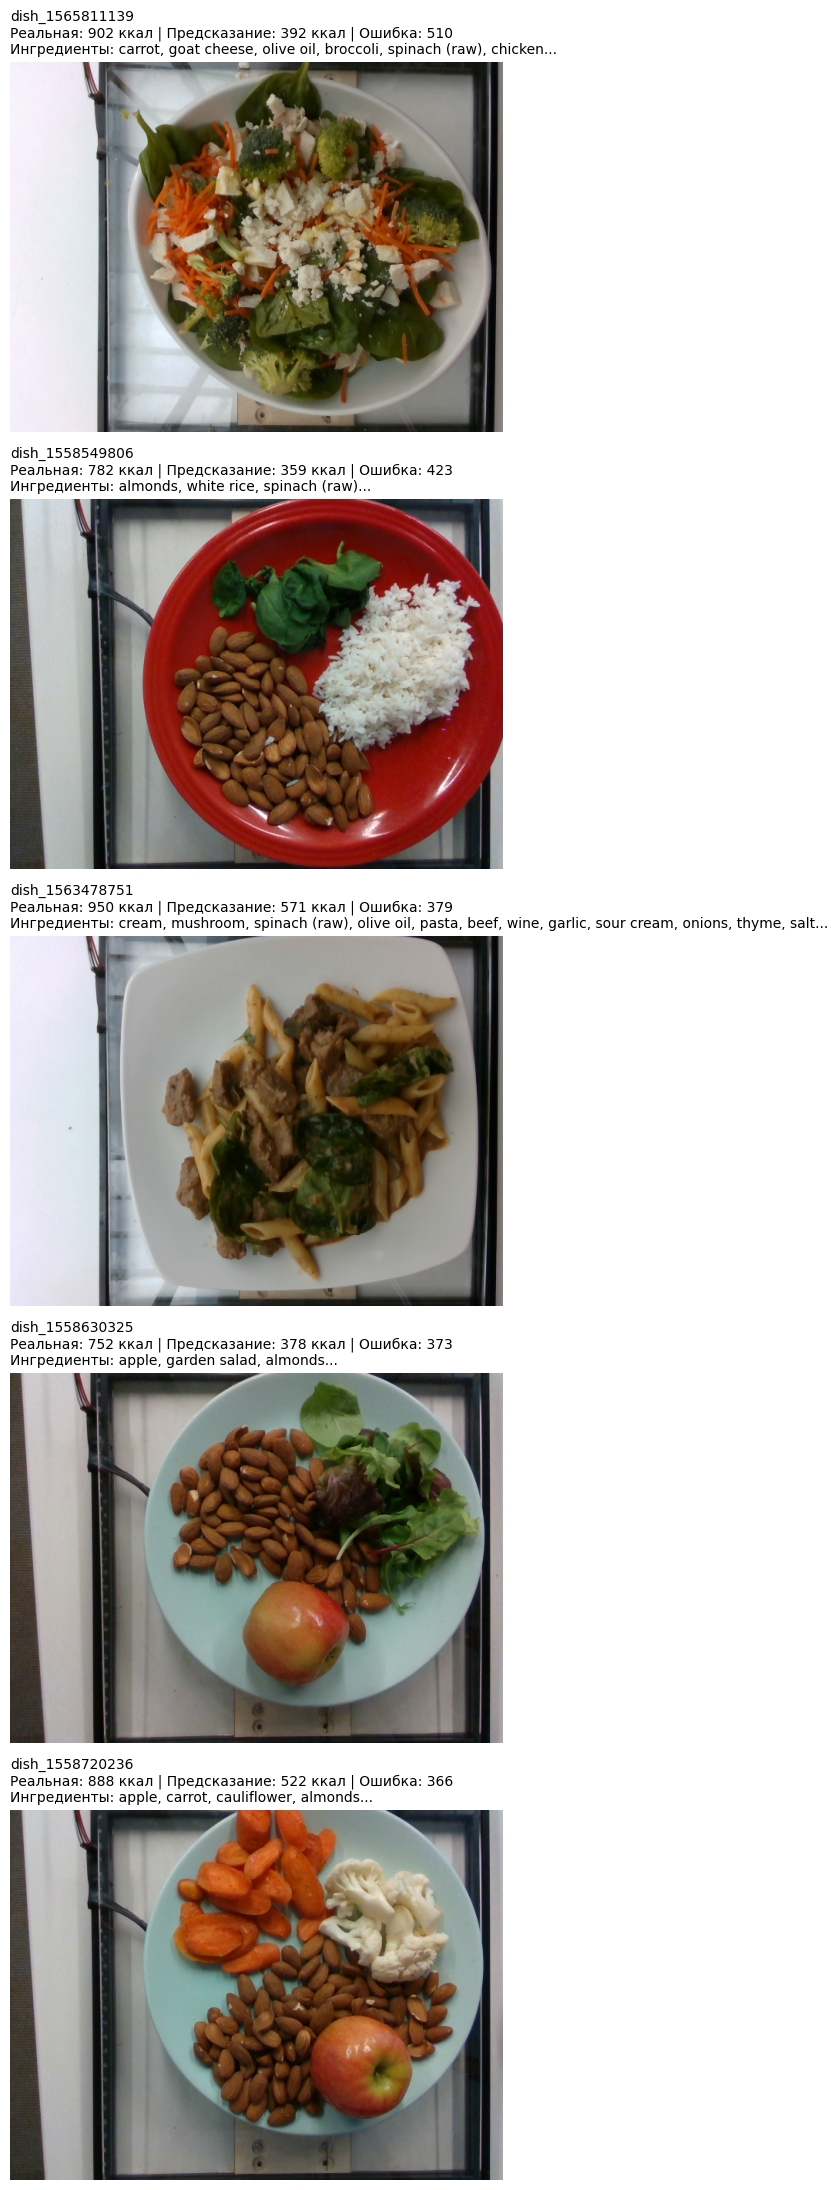

In [23]:
from PIL import Image

fig, axes = plt.subplots(5, 1, figsize=(12, 22))

for i, row in top5.iterrows():
    dish_id = row['dish_id']

    img_path = os.path.join(cfg.DATA_DIR, "images", str(dish_id), "rgb.png")
    img = Image.open(img_path)

    dish_info = test_df[test_df['dish_id'] == dish_id].iloc[0]
    ingredients = dish_info['ingredients_text']

    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title(
        f"{dish_id}\n"
        f"Реальная: {row['target']:.0f} ккал | "
        f"Предсказание: {row['pred']:.0f} ккал | "
        f"Ошибка: {row['abs_error']:.0f}\n"
        f"Ингредиенты: {ingredients[:120]}...",
        fontsize=10, loc='left'
    )

plt.tight_layout()
plt.show()

In [24]:
for i, row in top5.iterrows():
    dish_id = row['dish_id']
    dish_info = test_df[test_df['dish_id'] == dish_id].iloc[0]

    print(f"\n{'='*80}")
    print(f"Блюдо {i+1}: {dish_id}")
    print(f"Реальная калорийность: {row['target']:.1f} ккал")
    print(f"Предсказание модели:   {row['pred']:.1f} ккал")
    print(f"Абсолютная ошибка:     {row['abs_error']:.1f} ккал")
    print(f"Масса порции:          {dish_info['total_mass']:.0f} г")
    print(f"Ингредиенты: {dish_info['ingredients_text']}")


Блюдо 1: dish_1565811139
Реальная калорийность: 902.2 ккал
Предсказание модели:   392.3 ккал
Абсолютная ошибка:     509.9 ккал
Масса порции:          416 г
Ингредиенты: carrot, goat cheese, olive oil, broccoli, spinach (raw), chicken

Блюдо 2: dish_1558549806
Реальная калорийность: 782.0 ккал
Предсказание модели:   359.3 ккал
Абсолютная ошибка:     422.7 ккал
Масса порции:          203 г
Ингредиенты: almonds, white rice, spinach (raw)

Блюдо 3: dish_1563478751
Реальная калорийность: 950.4 ккал
Предсказание модели:   571.4 ккал
Абсолютная ошибка:     379.0 ккал
Масса порции:          545 г
Ингредиенты: cream, mushroom, spinach (raw), olive oil, pasta, beef, wine, garlic, sour cream, onions, thyme, salt

Блюдо 4: dish_1558630325
Реальная калорийность: 751.5 ккал
Предсказание модели:   378.2 ккал
Абсолютная ошибка:     373.3 ккал
Масса порции:          269 г
Ингредиенты: apple, garden salad, almonds

Блюдо 5: dish_1558720236
Реальная калорийность: 887.8 ккал
Предсказание модели:   522.3 

##Выводы: Анализ ошибок

### Анализ ошибок

Финальный MAE на тестовой выборке — 60.62 ккал. Это выше целевого порога MAE < 50, поэтому разберём 5 блюд с наибольшей ошибкой — они показывают системную проблему модели.

**Топ-5 ошибок:**

| # | Блюдо | Реально | Предсказано | Ошибка | Масса | Ингредиенты |
|---|---|---|---|---|---|---|
| 1 | dish_1565811139 | 902 | 392 | 510 | 416 г | курица, козий сыр, оливковое масло, овощи |
| 2 | dish_1558549806 | 782 | 359 | 423 | 203 г | миндаль, белый рис, шпинат |
| 3 | dish_1563478751 | 950 | 571 | 379 | 545 г | паста, говядина, сливки, сметана, вино |
| 4 | dish_1558630325 | 752 | 378 | 373 | 269 г | яблоко, салат, миндаль |
| 5 | dish_1558720236 | 888 | 522 | 366 | 407 г | яблоко, морковь, цветная капуста, миндаль |

**Ключевое наблюдение: все 5 ошибок — это недооценка калорийности.** Модель занижает предсказания на 40–55% на калорийных блюдах. Это не случайный шум, а системная проблема.

**Основные причины:**

1. **Отсутствие массы порции на входе.** Модель не знает, сколько весит блюдо. Она видит ингредиенты и фото, но не может понять, что 416 г курицы с сыром и маслом — это 900 ккал, а не 400. Корреляция массы и калорийности в датасете составляет 0.76 (Пирсон) и 0.78 (Спирмен) — это сильная связь, которую модель не использует.

2. **Длинный правый хвост распределения.** Блюд с калорийностью выше 700 ккал всего **3.8%** от датасета. Модель, обучаясь на средних значениях, «недоучивается» на выбросах и предсказывает в районе медианы (209 ккал).

3. **Скрытые калорийные ингредиенты.** Три из пяти блюд содержат **миндаль** — очень калорийный продукт (600 ккал на 100 г). Модель, вероятно, воспринимает его как «орехи в салате» и не учитывает, что его там может быть 50–100 г. Похожая ситуация с оливковым маслом, сливками, сметаной, сыром — они калорийны, но в текстовом описании выглядят как обычные ингредиенты.

4. **Ложные ассоциации по «лёгким» ингредиентам.** В списках много овощей (шпинат, морковь, цветная капуста), и модель интерпретирует блюдо как «салат», занижая калорийность. Реально же основной вклад дают масла, сыры, орехи, мясо.

5. **Недостаток разнообразия в обучающей выборке.** Калорийных блюд в train мало, и модель не может выучить их паттерны.

**Возможные направления улучшения:**

- Добавить в модель массу порции как входной признак — самое очевидное улучшение, но по условию задания масса не подаётся на вход.
- Взвешивать лосс так, чтобы ошибки на калорийных блюдах вносили больший вклад в обучение (например, использовать weighted L1Loss или Huber loss с большим delta).
- Увеличить размер батча или применить gradient accumulation для стабилизации обучения.
- Использовать более сильный image-энкодер (например, `convnext_tiny` или `efficientnet_b3`).
- Обучать дольше с early stopping и cosine learning rate scheduler.
- Применить усреднение нескольких чекпоинтов (snapshot ensemble) для стабилизации предсказаний.
- Провести аугментацию данных для редких калорийных блюд (например, oversampling).